In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [8]:
titanic_test = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/test.csv")
titanic_train = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/train.csv")
titanic_gen_sub = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/gender_submission.csv")

## <b> <center> EXPLORATORY DATA ANALYSIS </center> </b>

In [9]:
titanic_train.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
85,86,1,3,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...",female,33.0,3,0,3101278,15.8500,NaN,S
416,417,1,2,"Drew, Mrs. James Vivian (Lulu Thorne Christian)",female,34.0,1,1,28220,32.5000,NaN,S
80,81,0,3,"Waelens, Mr. Achille",male,22.0,0,0,345767,9.0000,NaN,S
727,728,1,3,"Mannion, Miss. Margareth",female,NaN,0,0,36866,7.7375,NaN,Q
238,239,0,2,"Pengelly, Mr. Frederick William",male,19.0,0,0,28665,10.5000,NaN,S
346,347,1,2,"Smith, Miss. Marion Elsie",female,40.0,0,0,31418,13.0000,NaN,S
746,747,0,3,"Abbott, Mr. Rossmore Edward",male,16.0,1,1,C.A. 2673,20.2500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
635,636,1,2,"Davis, Miss. Mary",female,28.0,0,0,237668,13.0000,NaN,S
701,702,1,1,"Silverthorne, Mr. Spencer Victor",male,35.0,0,0,PC 17475,26.2875,E24,S


In [10]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
titanic_train.shape

(891, 12)

In [12]:
titanic_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [13]:
titanic_train.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
titanic_train.describe(include = 'all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [15]:
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
titanic_train.duplicated().sum()

np.int64(0)

In [17]:
titanic_train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## <b><center>Exploratory Data Analysis</b>

In [18]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [19]:
df = titanic_train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [20]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [21]:
df.shape

(891, 8)

In [22]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\1419413682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Survived'], color='skyblue', palette=['lightblue', 'salmon'])


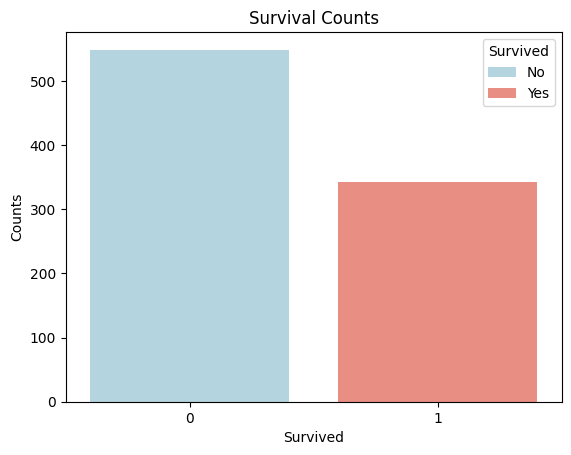

In [23]:
plt.figsize = (12, 5)

sns.countplot(x = df['Survived'], color='skyblue', palette=['lightblue', 'salmon'])
plt.title('Survival Counts')
plt.xlabel("Survived")
plt.ylabel("Counts")

plt.legend(title = 'Survived', labels = ['No', 'Yes'])

plt.show()

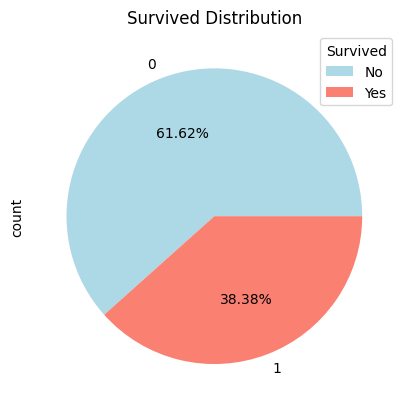

In [24]:
plt.figsize = (12, 5)

df['Survived'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon'])

plt.title("Survived Distribution")
plt.legend(title = 'Survived', labels = ['No', 'Yes'])

plt.show()

In [25]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\122211628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Pclass'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])


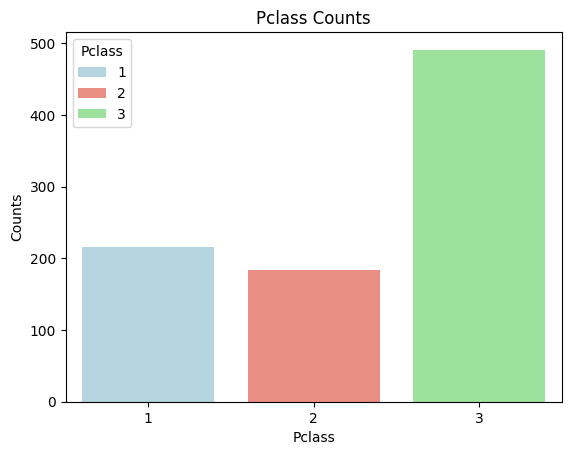

In [26]:
plt.figsize = (12, 5)

sns.countplot(x = df['Pclass'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])
plt.title('Pclass Counts')
plt.xlabel("Pclass")
plt.ylabel("Counts")

plt.legend(title = 'Pclass', labels = ['1', '2', '3'])

plt.show()

In [27]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

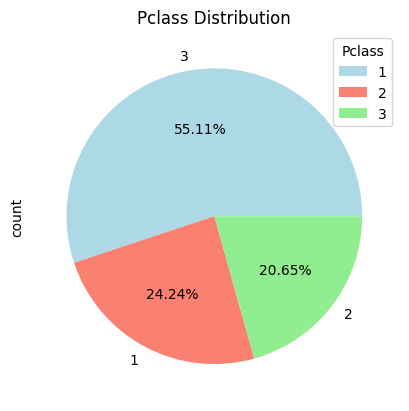

In [28]:
plt.figsize = (12, 5)

df['Pclass'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen'])

plt.title("Pclass Distribution")
plt.legend(title = 'Pclass', labels = ['1', '2', '3'])

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\2357880717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Sex'], color='skyblue', palette=['lightblue', 'salmon'])


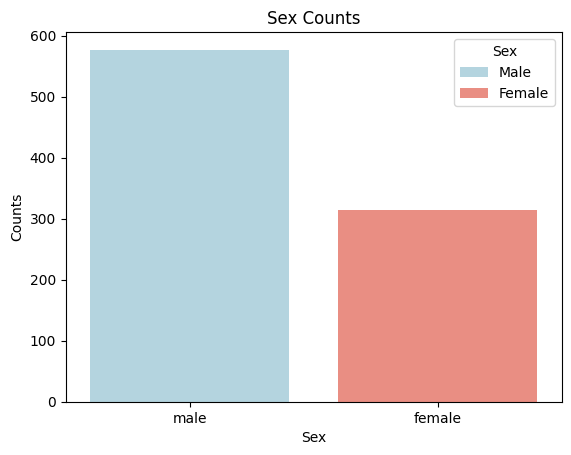

In [29]:
plt.figsize = (12, 5)

sns.countplot(x = df['Sex'], color='skyblue', palette=['lightblue', 'salmon'])
plt.title('Sex Counts')
plt.xlabel("Sex")
plt.ylabel("Counts")

plt.legend(title = 'Sex', labels = ['Male', 'Female'])

plt.show()

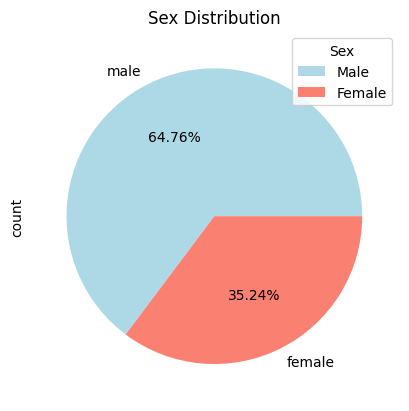

In [30]:
plt.figsize = (12, 5)

df['Sex'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon'])

plt.title("Sex Distribution")
plt.legend(title = 'Sex', labels = ['Male', 'Female'])

plt.show()

In [31]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\3655727618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])
C:\Users\Home\AppData\Local\Temp\ipykernel_43624\3655727618.py:3: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])


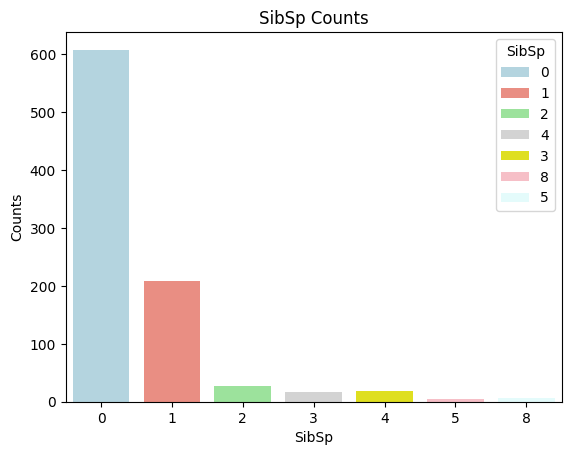

In [32]:
plt.figsize = (12, 5)

sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])
plt.title('SibSp Counts')
plt.xlabel("SibSp")
plt.ylabel("Counts")

plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

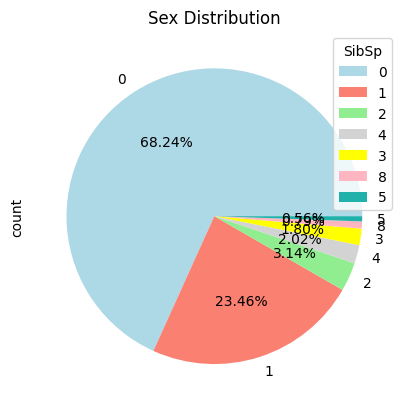

In [33]:
plt.figsize = (12, 5)

df['SibSp'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Sex Distribution")
plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

In [34]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\2915405946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Parch'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])


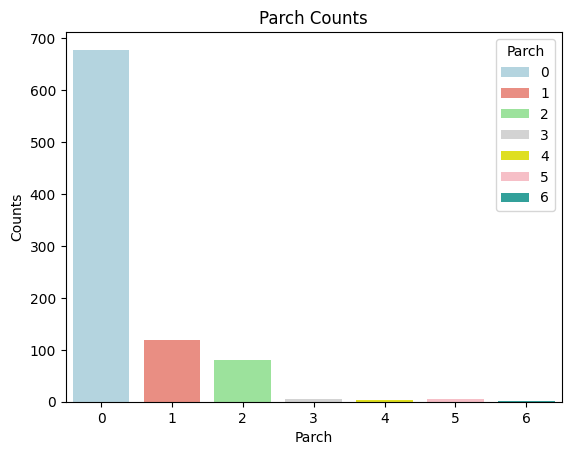

In [35]:
plt.figsize = (12, 5)

sns.countplot(x = df['Parch'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])
plt.title('Parch Counts')
plt.xlabel("Parch")
plt.ylabel("Counts")

plt.legend(title = 'Parch', labels = ['0', '1', '2', '3', '4', '5', '6'])

plt.show()

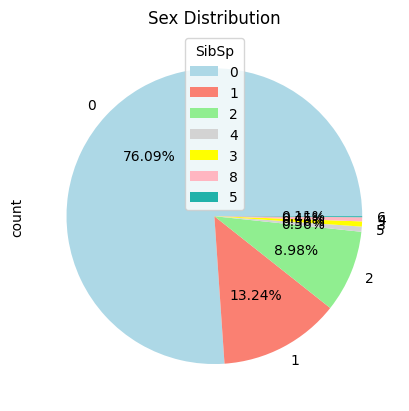

In [36]:
plt.figsize = (12, 5)

df['Parch'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Sex Distribution")
plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

In [37]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\3126860859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Embarked'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])


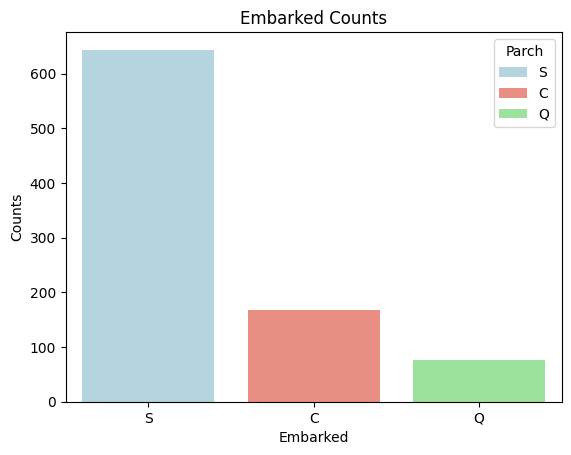

In [38]:
plt.figsize = (12, 5)

sns.countplot(x = df['Embarked'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])
plt.title('Embarked Counts')
plt.xlabel("Embarked")
plt.ylabel("Counts")

plt.legend(title = 'Parch', labels = ['S', 'C', 'Q'])

plt.show()

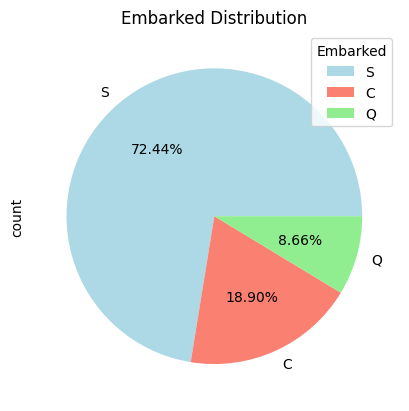

In [39]:
plt.figsize = (12, 5)

df['Embarked'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Embarked Distribution")
plt.legend(title = 'Embarked', labels = ['S', 'C', 'Q'])

plt.show()

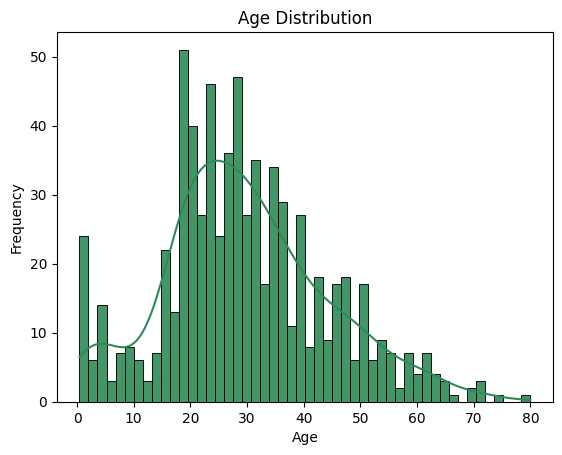

In [40]:
sns.histplot(x = df['Age'], kde = True, color = 'seagreen', bins = 50,  edgecolor = 'black', alpha = 0.9)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

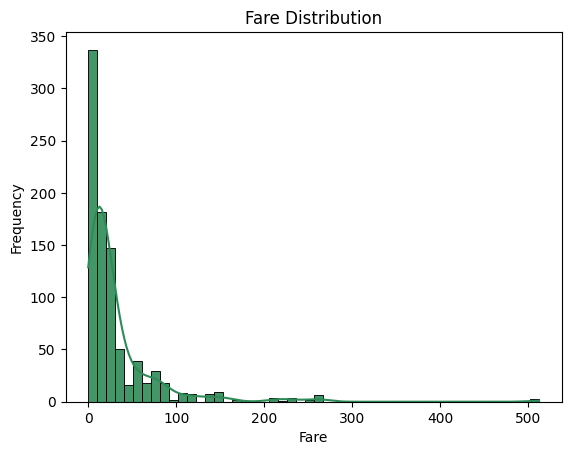

In [41]:
sns.histplot(x = df['Fare'], kde = True, color = 'seagreen', bins = 50,  edgecolor = 'black', alpha = 0.9)

plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Distribution")

plt.show()

In [42]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


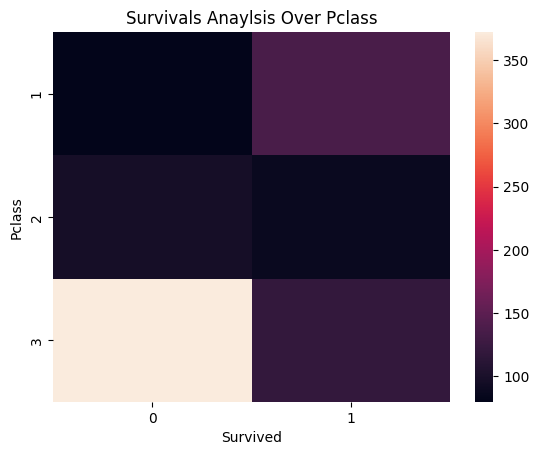

In [43]:
sns.heatmap(pd.crosstab(df['Pclass'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Pclass")
plt.title("Survivals Anaylsis Over Pclass")

plt.show()

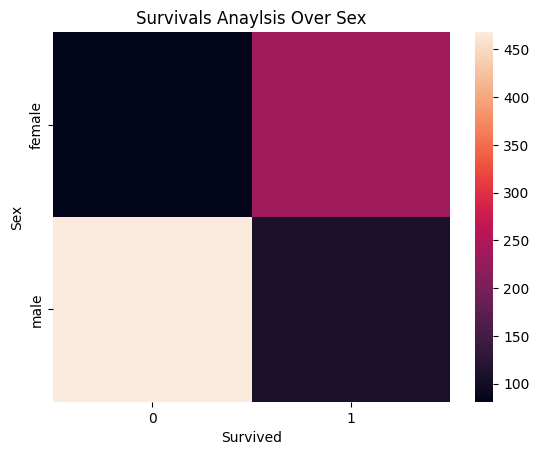

In [44]:
sns.heatmap(pd.crosstab(df['Sex'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Sex")
plt.title("Survivals Anaylsis Over Sex")

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\4084794426.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Age'], hist = False, color = 'lightgreen')
C:\Users\Home\AppData\Local\Temp\ipykernel_43624\4084794426.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  s

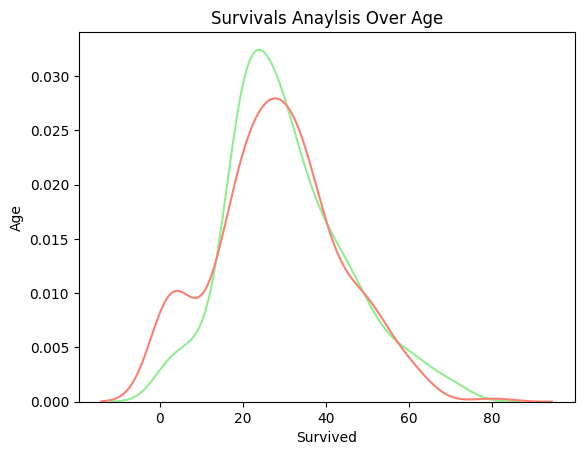

In [45]:
sns.distplot(df[df['Survived']==0]['Age'], hist = False, color = 'lightgreen')
sns.distplot(df[df['Survived']==1]['Age'], hist = False, color = 'salmon')

plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Survivals Anaylsis Over Age")

plt.show()

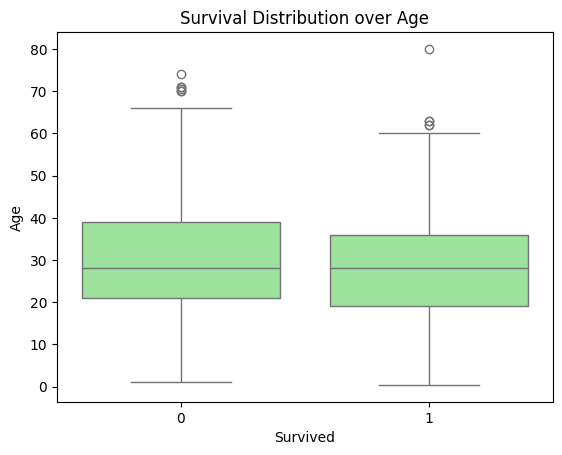

In [46]:
sns.boxplot(x = df['Survived'], y = df['Age'], data = df, color = 'lightgreen')

plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Survival Distribution over Age")

plt.show()

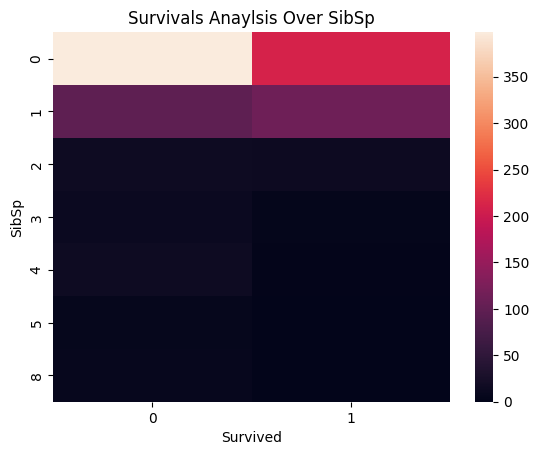

In [47]:
sns.heatmap(pd.crosstab(df['SibSp'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("SibSp")
plt.title("Survivals Anaylsis Over SibSp")

plt.show()

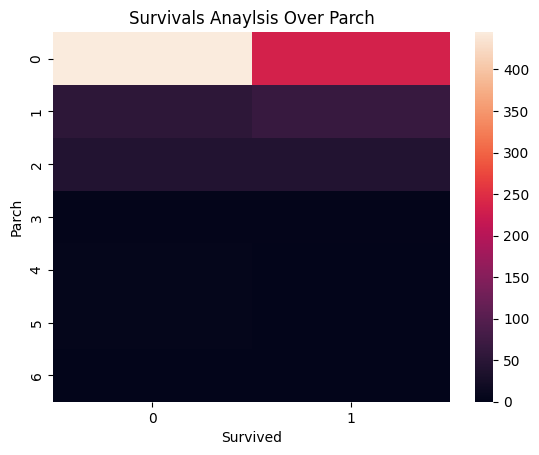

In [48]:
sns.heatmap(pd.crosstab(df['Parch'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Parch")
plt.title("Survivals Anaylsis Over Parch")

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\1203803857.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Fare'], hist = False, color = 'lightgreen')
C:\Users\Home\AppData\Local\Temp\ipykernel_43624\1203803857.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  

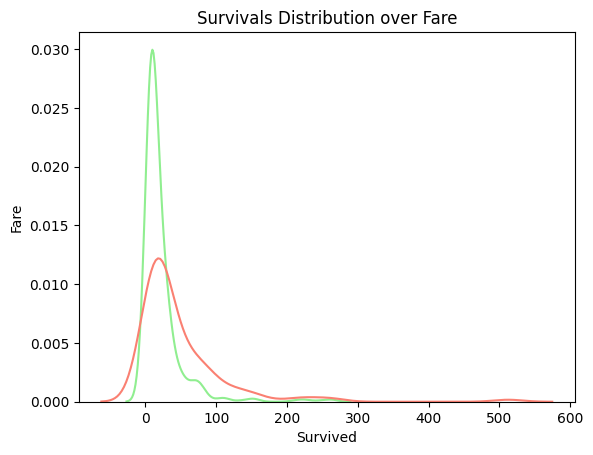

In [49]:
sns.distplot(df[df['Survived']==0]['Fare'], hist = False, color = 'lightgreen')
sns.distplot(df[df['Survived']==1]['Fare'], hist = False, color = 'salmon')

plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Survivals Distribution over Fare")

plt.show()

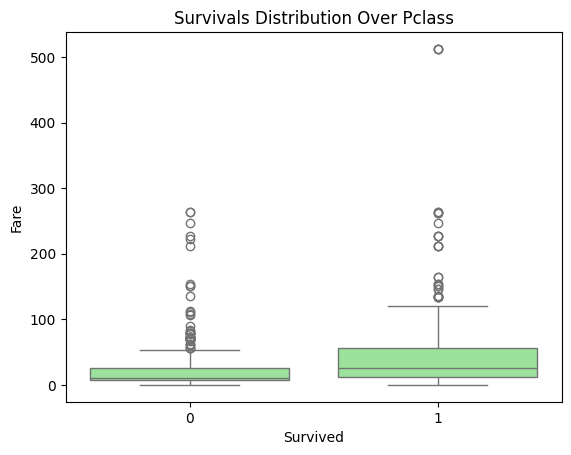

In [50]:
sns.boxplot(x = df['Survived'], y = df['Fare'], data = df, color = 'lightgreen')

plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Survivals Distribution Over Pclass")

plt.show()

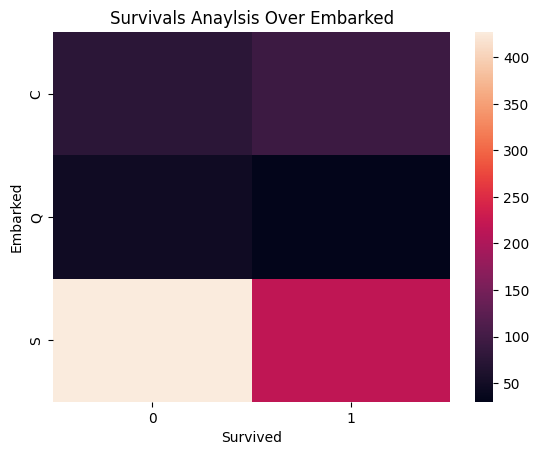

In [51]:
sns.heatmap(pd.crosstab(df['Embarked'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Embarked")
plt.title("Survivals Anaylsis Over Embarked")

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\4236982072.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pclass']==1]['Age'], hist = False)
C:\Users\Home\AppData\Local\Temp\ipykernel_43624\4236982072.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pclas

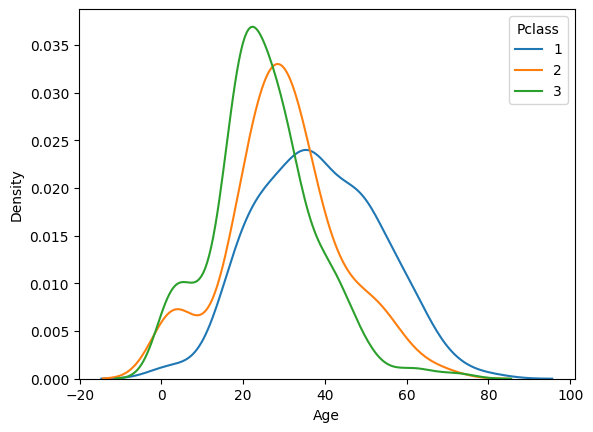

In [52]:
sns.distplot(df[df['Pclass']==1]['Age'], hist = False)
sns.distplot(df[df['Pclass']==2]['Age'], hist = False)
sns.distplot(df[df['Pclass']==3]['Age'], hist = False)

plt.legend(title = "Pclass", labels = ['1', '2', '3'])

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\1509461532.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pclass'] == 1]['Fare'], hist = False)
C:\Users\Home\AppData\Local\Temp\ipykernel_43624\1509461532.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pc

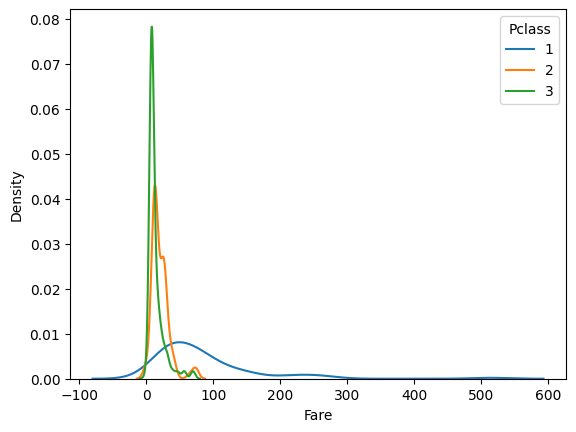

In [53]:
sns.distplot(df[df['Pclass'] == 1]['Fare'], hist = False)
sns.distplot(df[df['Pclass'] == 2]['Fare'], hist = False)
sns.distplot(df[df['Pclass'] == 3]['Fare'], hist = False)

plt.legend(title = "Pclass", labels = ['1', '2', '3'])

plt.show()

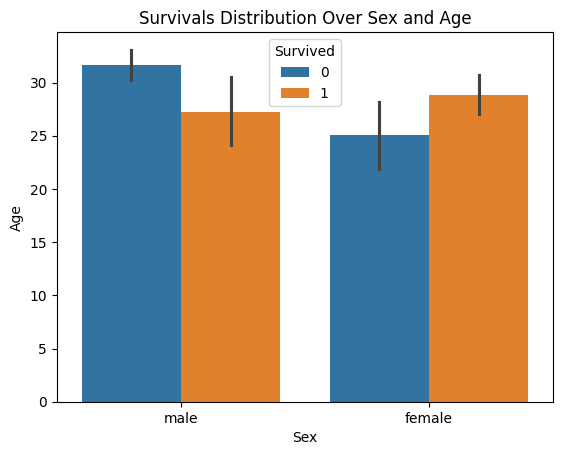

In [54]:
sns.barplot(x = df['Sex'], y = df['Age'], hue = df['Survived'], data = df)

plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Survivals Distribution Over Sex and Age")

plt.show()

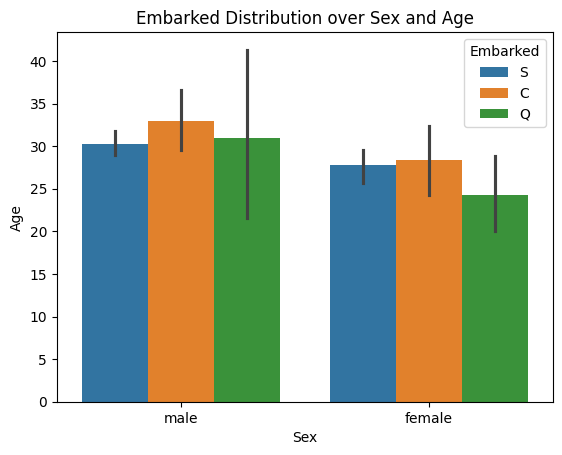

In [55]:
sns.barplot(x = df['Sex'], y = df['Age'], hue = df['Embarked'], data = df)

plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Embarked Distribution over Sex and Age")

plt.show()

In [56]:
df['Family'] = df['SibSp'] + df['Parch']

df[['Family']]

,Family
0,1
1,1
2,0
3,1
4,0
...,...
886,0
887,0
888,3
889,0


In [57]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family
0,0,3,male,22.0,1,0,7.2500,S,1
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


In [58]:
df.drop(columns = ['SibSp', 'Parch'], inplace = True)

In [59]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0


In [60]:
df.shape

(891, 7)

In [61]:
df['Family'].value_counts()

Family
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

<Axes: xlabel='Family'>

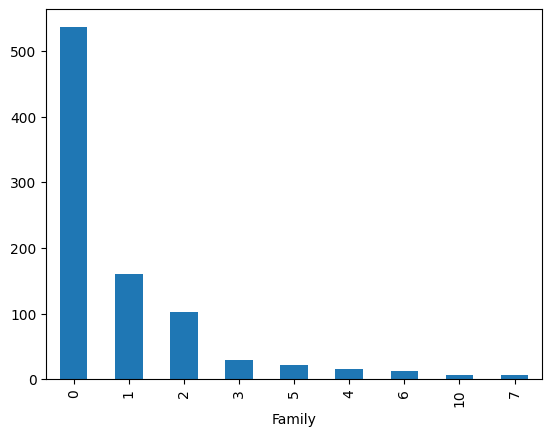

In [62]:
df['Family'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

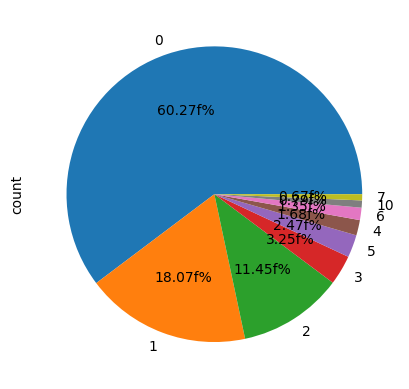

In [63]:
df['Family'].value_counts().plot(kind = 'pie', autopct = '%.2ff%%')

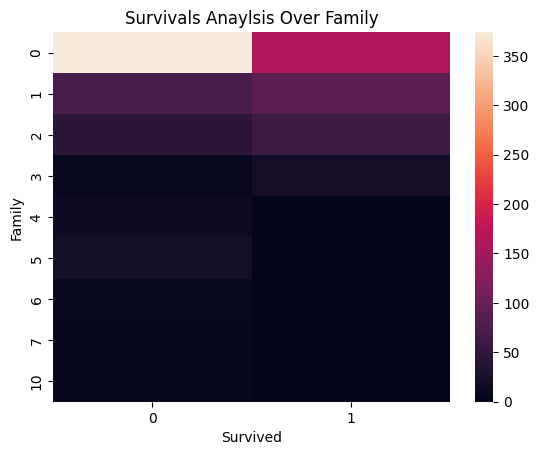

In [58]:
sns.heatmap(pd.crosstab(df['Family'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Family")
plt.title("Survivals Anaylsis Over Family")

plt.show()

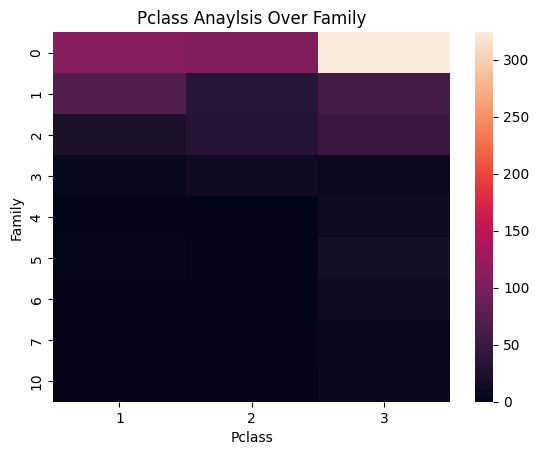

In [59]:
sns.heatmap(pd.crosstab(df['Family'], df['Pclass']))

plt.xlabel("Pclass")
plt.ylabel("Family")
plt.title("Pclass Anaylsis Over Family")

plt.show()

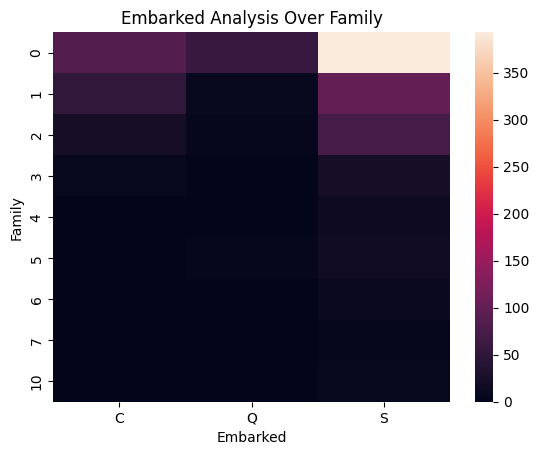

In [65]:
sns.heatmap(pd.crosstab(df['Family'], df['Embarked']))

plt.xlabel("Embarked")
plt.ylabel("Family")
plt.title("Embarked Analysis Over Family")

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\956497331.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df['Family']==fam]['Age'], ax=axes[row, col])


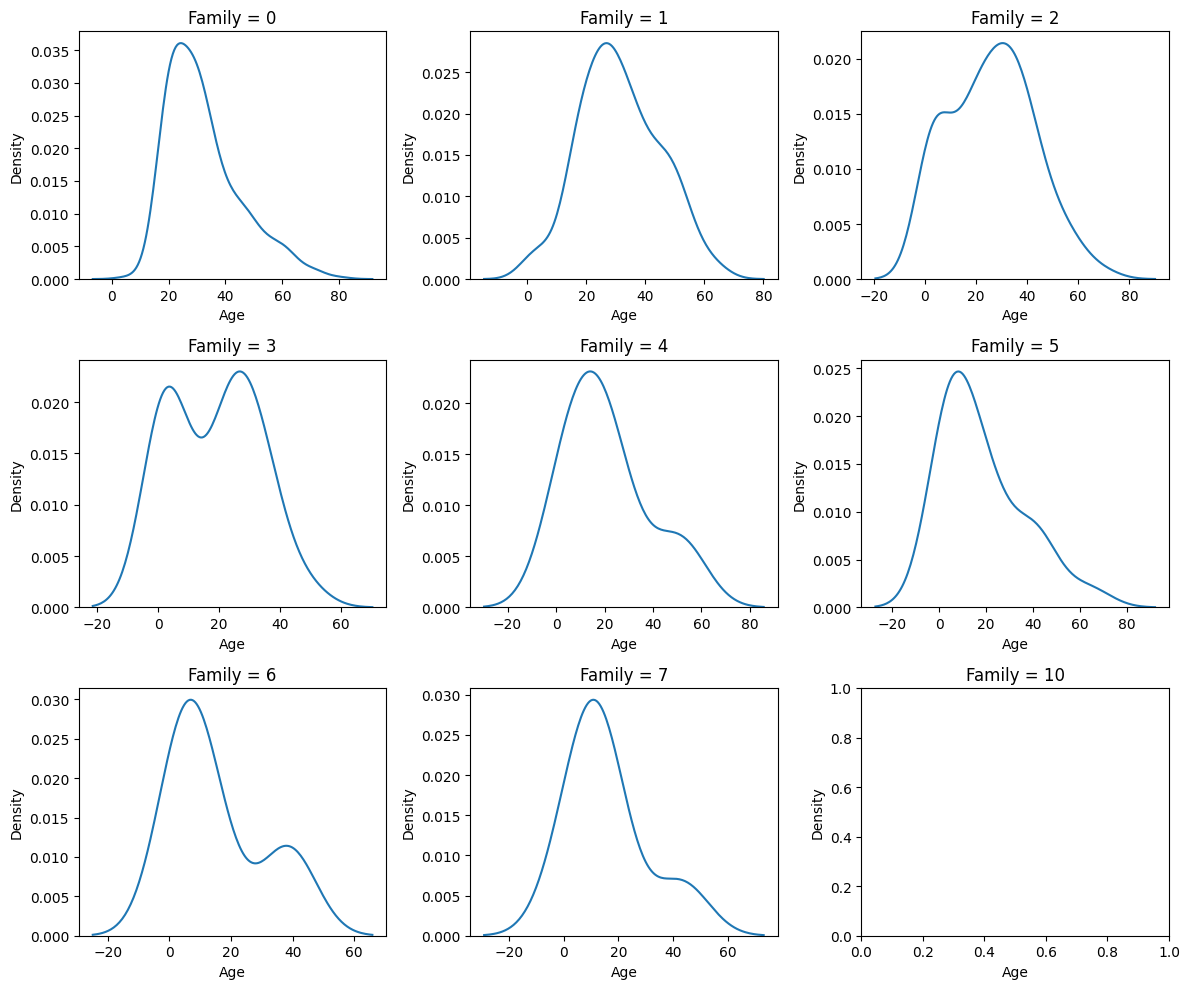

In [ ]:
family_sizes = [0,1,2,3,4,5,6,7,10]

fig, axes = plt.subplots(3,3, figsize=(12,10))

for i, fam in enumerate(family_sizes):
    row = i // 3
    col = i % 3
    
    sns.kdeplot(df[df['Family']==fam]['Age'], ax=axes[row, col])
    axes[row, col].set_title(f'Family = {fam}')

plt.tight_layout()
plt.show()

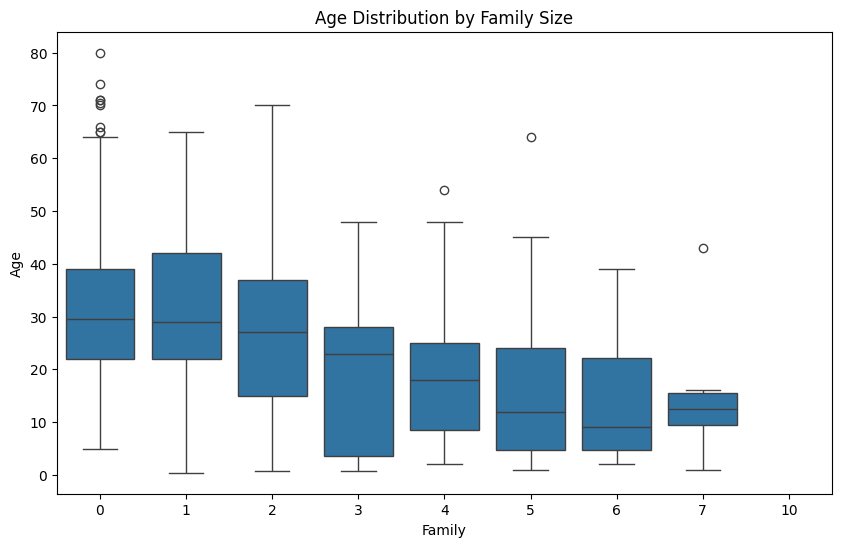

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Family', y='Age', data=df)

plt.title('Age Distribution by Family Size')
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_43624\1973066401.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df['Family']==fam]['Fare'], ax=axes[row, col])
C:\Users\Home\AppData\Local\Temp\ipykernel_43624\1973066401.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df['Family']==fam]['Fare'], ax=axes[row, col])


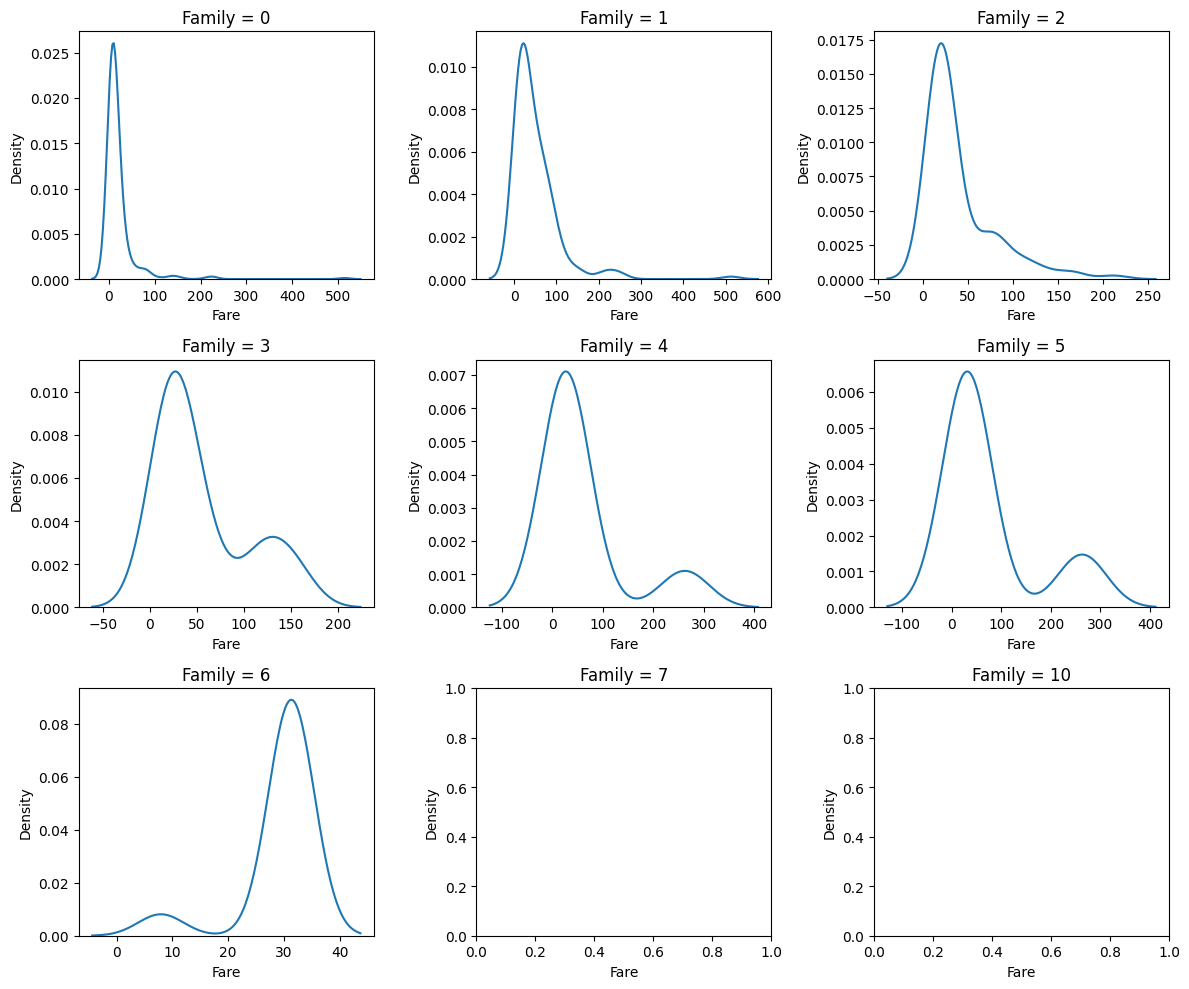

In [73]:
family_sizes = [0,1,2,3,4,5,6,7,10]

fig, axes = plt.subplots(3,3, figsize=(12,10))

for i, fam in enumerate(family_sizes):
    row = i // 3
    col = i % 3
    
    sns.kdeplot(df[df['Family']==fam]['Fare'], ax=axes[row, col])
    axes[row, col].set_title(f'Family = {fam}')

plt.tight_layout()
plt.show()

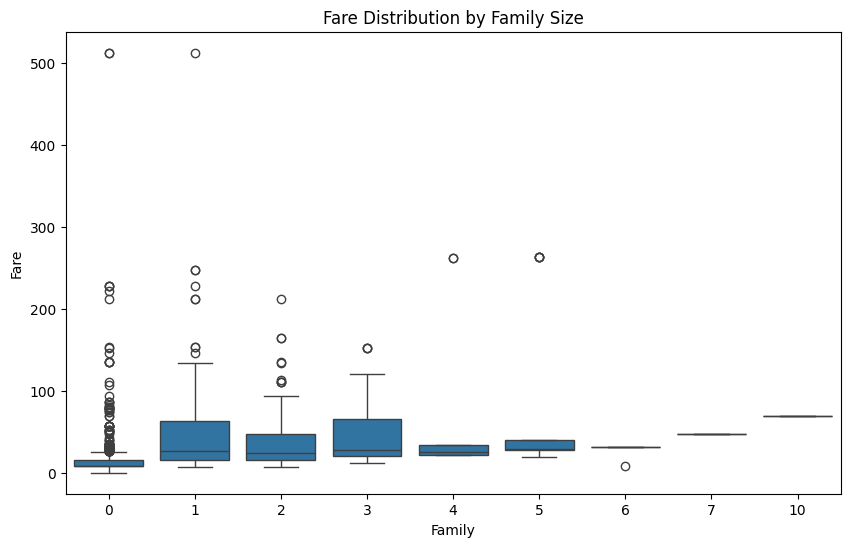

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Family', y='Fare', data=df)

plt.title('Fare Distribution by Family Size')
plt.show()